# Risk attribution

In [51]:
"""
Magic commands
"""

%load_ext autoreload
%autoreload 2

"""
Python packages
"""

import os
import sys

import seaborn as sns
import numpy as np
from scipy import stats, optimize
import pandas as pd
import matplotlib.pyplot as plt

import datetime

# remember to install pandas-datareader  if not installed
from pandas_datareader.famafrench import FamaFrenchReader, get_available_datasets

"""
Own packages
"""

try:
    import corelib
except ModuleNotFoundError:
    sys.path.insert(0, 'C:\\code\\corelib\\')

# risk attribution
from corelib.alm.portfolio_optimization.risk_attribution import LFMRiskAttribution
    
# plotting 
from corelib.plotting import pensam_colors, PenSamStyle, number_format, rescale_plotting_window, fan_chart, waterfall_chart

pensam_color_codes = list(pensam_colors.values());
PenSamStyle();

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Introduction 

This notebook illustrates how to perform risk attribution. If we can write e.g. the return $\boldsymbol{Y}$ as a linear function of a set of risk drives $\boldsymbol{Z}$

$$
\boldsymbol{Y} = \boldsymbol{\beta} \boldsymbol{Z}
$$

Then, we can use the Euler principle to allocate the marginal risk contribution to the different factors. We are assuming that a possible idiosyncratic error is included in the factors. 

If the risk measure is homogenous of degree one, we could write 

$$
RC_i = \beta_i \frac{\partial \rho (\boldsymbol{\beta} \boldsymbol{Z})}{\partial \beta_i}
$$

where $\rho()$ is the risk measure.  

## Fama-French data

In [52]:
ff_data = FamaFrenchReader('F-F_Research_Data_Factors', start="1990-01-01").read()
ff_data['DESCR']

'F-F Research Data Factors\n-------------------------\n\nThis file was created by CMPT_ME_BEME_RETS using the 202306 CRSP database. The 1-month TBill return is from Ibbotson and Associates, Inc. Copyright 2023 Kenneth R. French\n\n  0 : (402 rows x 4 cols)\n  1 : Annual Factors: January-December (33 rows x 4 cols)'

In [53]:
ff_monthly_returns = ff_data[0] / 100.0
ff_monthly_returns.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
1990-01,-0.0785,-0.0124,0.0085,0.0057
1990-02,0.0111,0.0099,0.0064,0.0057
1990-03,0.0183,0.0150,-0.0292,0.0064
1990-04,-0.0336,-0.0046,-0.0259,0.0069
1990-05,0.0842,-0.0253,-0.0383,0.0068


In [54]:
industry_data = FamaFrenchReader('17_Industry_Portfolios', start="1990-01-01").read()
industry_data['DESCR']

'17 Industry Portfolios\n----------------------\n\nThis file was created by CMPT_IND_RETS using the 202306 CRSP database. It contains value- and equal-weighted returns for 17 industry portfolios. The portfolios are constructed at the end of June. The annual returns are from January to December. Missing data are indicated by -99.99 or -999. Copyright 2023 Kenneth R. French\n\n  0 : Average Value Weighted Returns -- Monthly (402 rows x 17 cols)\n  1 : Average Equal Weighted Returns -- Monthly (402 rows x 17 cols)\n  2 : Average Value Weighted Returns -- Annual (33 rows x 17 cols)\n  3 : Average Equal Weighted Returns -- Annual (33 rows x 17 cols)\n  4 : Number of Firms in Portfolios (402 rows x 17 cols)\n  5 : Average Firm Size (402 rows x 17 cols)\n  6 : Sum of BE / Sum of ME (33 rows x 17 cols)\n  7 : Value-Weighted Average of BE/ME (33 rows x 17 cols)'

In [55]:
industry_monthly_return = industry_data[0] / 100.0
industry_monthly_return.columns = [_.strip() for _ in industry_monthly_return.columns]
industry_monthly_return.head()

,Food,Mines,Oil,Clths,Durbl,Chems,Cnsum,Cnstr,Steel,FabPr,Machn,Cars,Trans,Utils,Rtail,Finan,Other
Date,,,,,,,,,,,,,,,,,
1990-01,-0.0960,0.0419,-0.0436,-0.0960,-0.0704,-0.0792,-0.0711,-0.0545,-0.0878,-0.0473,-0.0209,-0.0324,-0.0573,-0.0535,-0.0610,-0.0978,-0.1099
1990-02,-0.0019,0.0009,0.0312,0.0246,0.0060,0.0277,-0.0224,0.0336,0.0324,0.0350,0.0369,0.0605,0.0431,0.0021,0.0180,0.0232,0.0087
1990-03,0.0552,-0.0491,-0.0066,0.0613,0.0424,0.0112,0.0442,0.0517,0.0628,0.0481,0.0397,0.0329,0.0512,-0.0075,0.0513,-0.0156,0.0346
1990-04,0.0057,-0.0873,-0.0349,-0.0151,-0.0590,-0.0371,0.0175,-0.0210,-0.0705,0.0016,-0.0141,-0.0394,-0.0420,-0.0551,-0.0225,-0.0424,-0.0291
1990-05,0.1159,0.0788,0.0618,0.0686,0.0651,0.0712,0.1036,0.1121,0.0731,0.0773,0.1004,0.0824,0.0753,0.0543,0.1169,0.0927,0.0991


## Factor decomposition

It is possible to estimate the factor loadings $\boldsymbol{\beta}$ using a regression linear factor model. Below, we perform a risk attribution using the Fama-French 3-factor model. 

In [56]:
lfm_ar = LFMRiskAttribution()

In [57]:
"""
Define inputs
"""

asset_id = 'Finan'

excess_returns = industry_monthly_return[asset_id] - ff_monthly_returns['RF'].values
factors = ff_monthly_returns.loc[:, ['Mkt-RF', 'SMB', 'HML']].values

In [58]:
risk_contributions = lfm_ar.calculate_std_risk_attribution(target_variable=excess_returns, factors=factors)
total_risk = np.sum(risk_contributions)

C:\code\corelib\corelib\plotting\base.py:380: FutureWarning: Behavior when concatenating bool-dtype and numeric-dtype arrays is deprecated; in a future version these will cast to object dtype (instead of coercing bools to numeric values). To retain the old behavior, explicitly cast bool-dtype arrays to numeric dtype.
  trans.loc[total_label] = total
C:\code\corelib\corelib\plotting\base.py:517: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


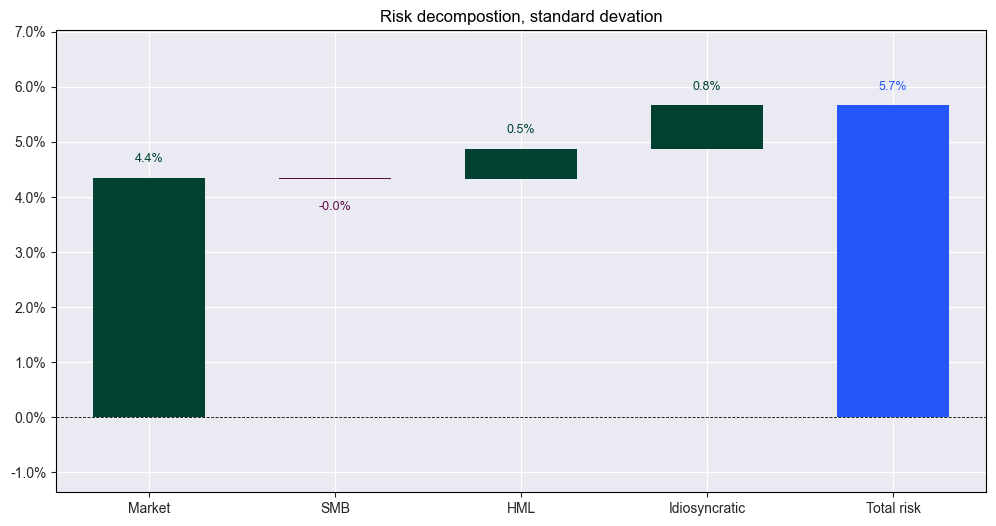

In [59]:
waterfall_chart(values=risk_contributions * 100,
                labels=["Market", "SMB", 'HML', 'Idiosyncratic'],
                formatting='{:,.1f}%',
                total_label="Total risk",
                title="Risk decompostion, standard devation");

fig = plt.gcf()
fig.set_size_inches(12, 6);

# Literature 